## Greatings this is Sunny Vishwakarama

and this assisment we have perform EDA With Anomaly ditection

## importing Required libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load Dataset


In [2]:
# Load the dataset from the URL into a DataFrame named 'df'
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1jpCNevXAiSKj6DURoe1Keno5GNrC9Ybw')

print("DataFrame 'df' loaded successfully.")
print(df.head())

DataFrame 'df' loaded successfully.
         Date  store  product  number_sold
0  2010-01-01      0        0          801
1  2010-01-02      0        0          810
2  2010-01-03      0        0          818
3  2010-01-04      0        0          796
4  2010-01-05      0        0          808


## Examine Data Structure

In [3]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230090 entries, 0 to 230089
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         230090 non-null  object
 1   store        230090 non-null  int64 
 2   product      230090 non-null  int64 
 3   number_sold  230090 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.0+ MB

Missing values per column:
Date           0
store          0
product        0
number_sold    0
dtype: int64


## Verify Date Range

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

min_date = df['Date'].min()
max_date = df['Date'].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2010-01-01 00:00:00
Maximum Date: 2018-12-31 00:00:00


## Descriptive Analysis

In [5]:
print("Descriptive statistics for 'number_sold':")
number_sold_stats = df['number_sold'].describe()

mean_sold = number_sold_stats['mean']
std_sold = number_sold_stats['std']
min_sold = number_sold_stats['min']
max_sold = number_sold_stats['max']

print(f"Mean number sold: {mean_sold:.2f}")
print(f"Standard Deviation of number sold: {std_sold:.2f}")
print(f"Minimum number sold: {min_sold}")
print(f"Maximum number sold: {max_sold}")

unique_stores = df['store'].nunique()
unique_products = df['product'].nunique()

print(f"\nNumber of unique stores: {unique_stores}")
print(f"Number of unique products: {unique_products}")

Descriptive statistics for 'number_sold':
Mean number sold: 780.93
Standard Deviation of number sold: 204.10
Minimum number sold: 238.0
Maximum number sold: 1205.0

Number of unique stores: 7
Number of unique products: 10


## Overall Data Distribution


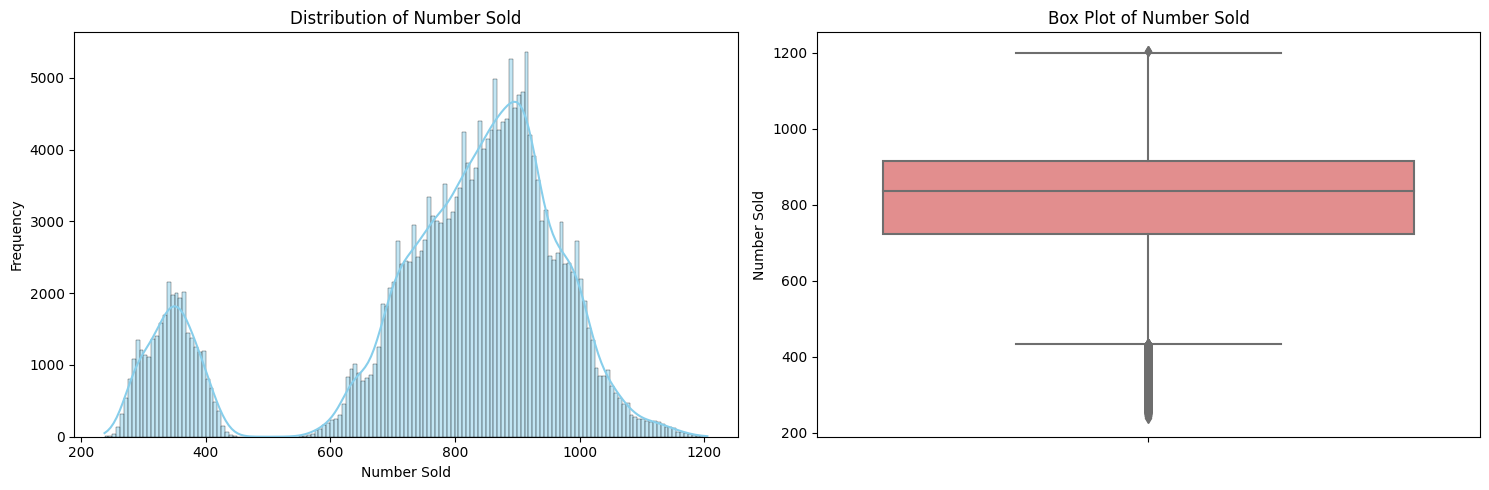

In [7]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot histogram on the first subplot
sns.histplot(df['number_sold'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Number Sold')
axes[0].set_xlabel('Number Sold')
axes[0].set_ylabel('Frequency')

# Plot box plot on the second subplot
sns.boxplot(y=df['number_sold'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot of Number Sold')
axes[1].set_ylabel('Number Sold')

plt.tight_layout()
plt.show()

The dataset contains 230,090 entries (rows) and 4 columns: 'Date', 'store', 'product', and 'number_sold'.
Initially, the 'Date' column was of type `object`. It was successfully converted to `datetime64[ns]` format. The 'store', 'product', and 'number_sold' columns are all of type `int64`
no missing values
The 'Date' column spans exactly from **2010-01-01 to 2018-12-31**
*   **Mean:** Approximately 780.93 sales per entry.
*   **Standard Deviation:** Approximately 204.10, indicating a moderate spread in sales figures.
*   **Minimum:** 238 sales.
*   **Maximum:** 1205 sales.


The dataset includes sales data for **7 unique stores** and **10 unique products**
without extreme outliers or bizarre patterns suggest that the data is well-prepared and ready for further

## Prepare Data for Time Series Analysis

In [9]:
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

overall_daily_sales = df.groupby(df.index)['number_sold'].sum()

print("DataFrame 'df' with 'Date' as index:")
print(df.head())
print("\nOverall Daily Sales Series:")
print(overall_daily_sales.head())
print(f"Type of overall_daily_sales: {type(overall_daily_sales)}")

DataFrame 'df' with 'Date' as index:
            store  product  number_sold
Date                                   
2010-01-01      0        0          801
2010-01-01      6        1          957
2010-01-01      4        9          947
2010-01-01      3        6          378
2010-01-01      1        1          745

Overall Daily Sales Series:
Date
2010-01-01    54870
2010-01-02    54960
2010-01-03    54863
2010-01-04    54926
2010-01-05    54634
Name: number_sold, dtype: int64
Type of overall_daily_sales: <class 'pandas.core.series.Series'>


## Analyze Overall Sales Trends

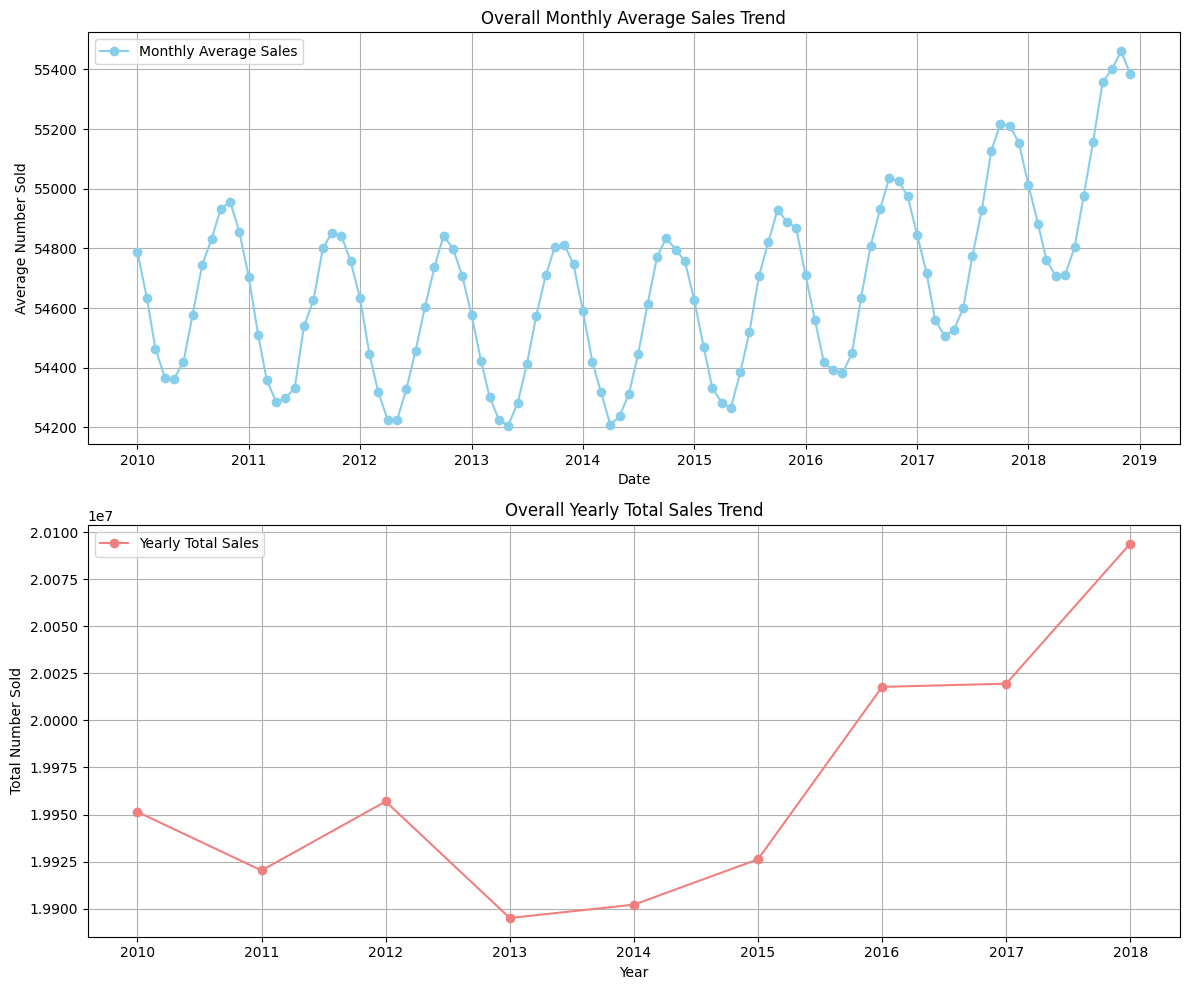

In [10]:
# 1. Resample to monthly frequency and calculate the mean
overall_monthly_avg_sales = overall_daily_sales.resample('MS').mean()

# 2. Resample to annual frequency and calculate the sum
overall_yearly_total_sales = overall_daily_sales.resample('AS').sum()

# 3. Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 4. Plot overall_monthly_avg_sales
axes[0].plot(overall_monthly_avg_sales.index, overall_monthly_avg_sales.values, marker='o', linestyle='-', color='skyblue', label='Monthly Average Sales')
axes[0].set_title('Overall Monthly Average Sales Trend')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Number Sold')
axes[0].grid(True)
axes[0].legend()

# 5. Plot overall_yearly_total_sales
axes[1].plot(overall_yearly_total_sales.index.year, overall_yearly_total_sales.values, marker='o', linestyle='-', color='lightcoral', label='Yearly Total Sales')
axes[1].set_title('Overall Yearly Total Sales Trend')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Number Sold')
axes[1].grid(True)
axes[1].set_xticks(overall_yearly_total_sales.index.year) # Set x-ticks to display each year clearly
axes[1].legend()

# 6. Ensure a tight layout and display the figure
plt.tight_layout()
plt.show()

## Analyze Product-Level Monthly Trends

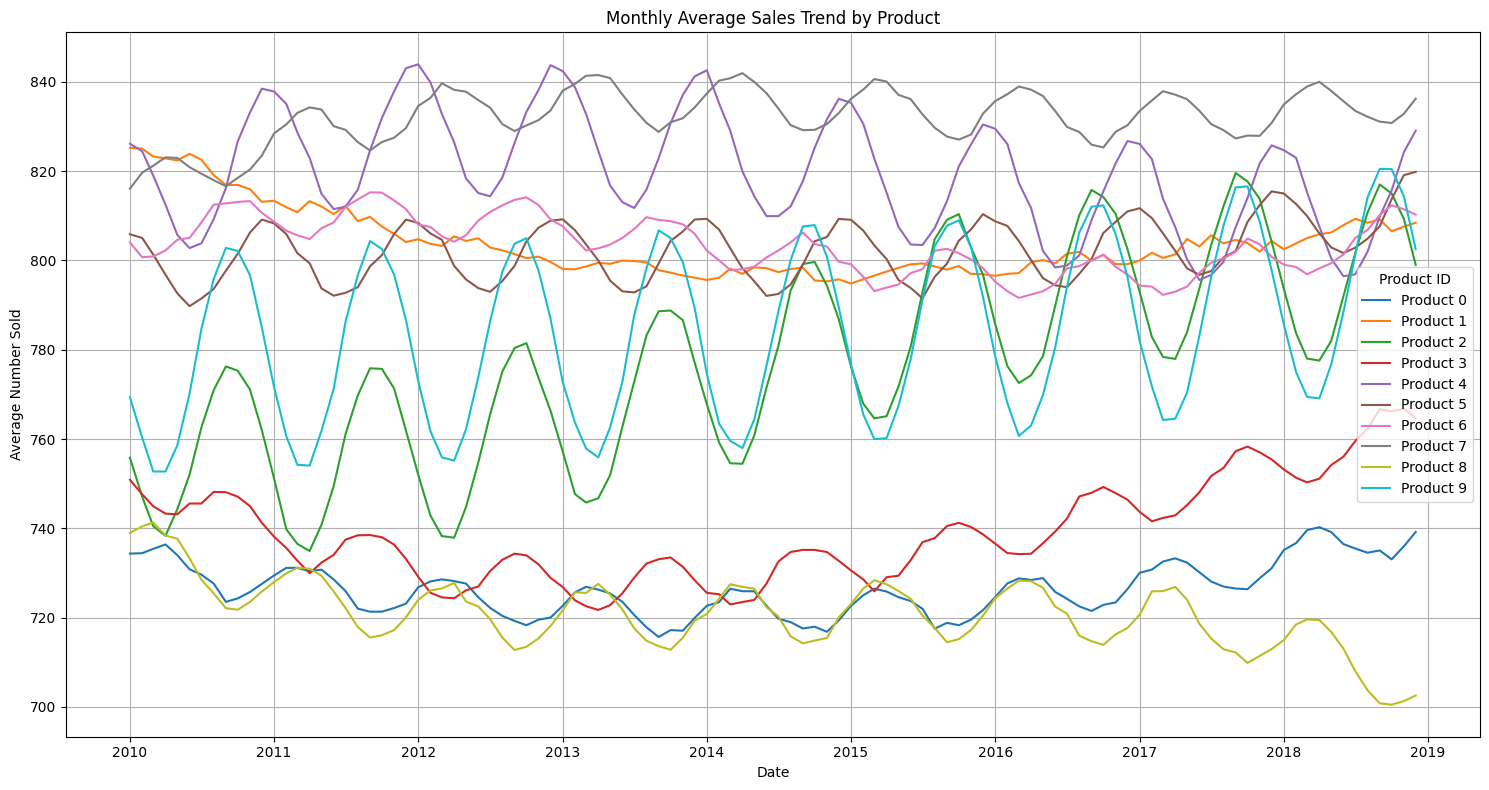

In [11]:
# Group by 'product', then resample 'number_sold' to monthly frequency and calculate the mean
product_monthly_avg_sales = df.groupby('product')['number_sold'].resample('MS').mean()

# Unstack to get products as columns for easier plotting
product_monthly_avg_sales_unstacked = product_monthly_avg_sales.unstack(level=0)

# Plotting the monthly average sales trend for each product
plt.figure(figsize=(15, 8))
for product_id in product_monthly_avg_sales_unstacked.columns:
    plt.plot(product_monthly_avg_sales_unstacked.index, product_monthly_avg_sales_unstacked[product_id], label=f'Product {product_id}')

plt.title('Monthly Average Sales Trend by Product')
plt.xlabel('Date')
plt.ylabel('Average Number Sold')
plt.legend(title='Product ID')
plt.grid(True)
plt.tight_layout()
plt.show()

## Perform Overall Sales Seasonal Decomposition

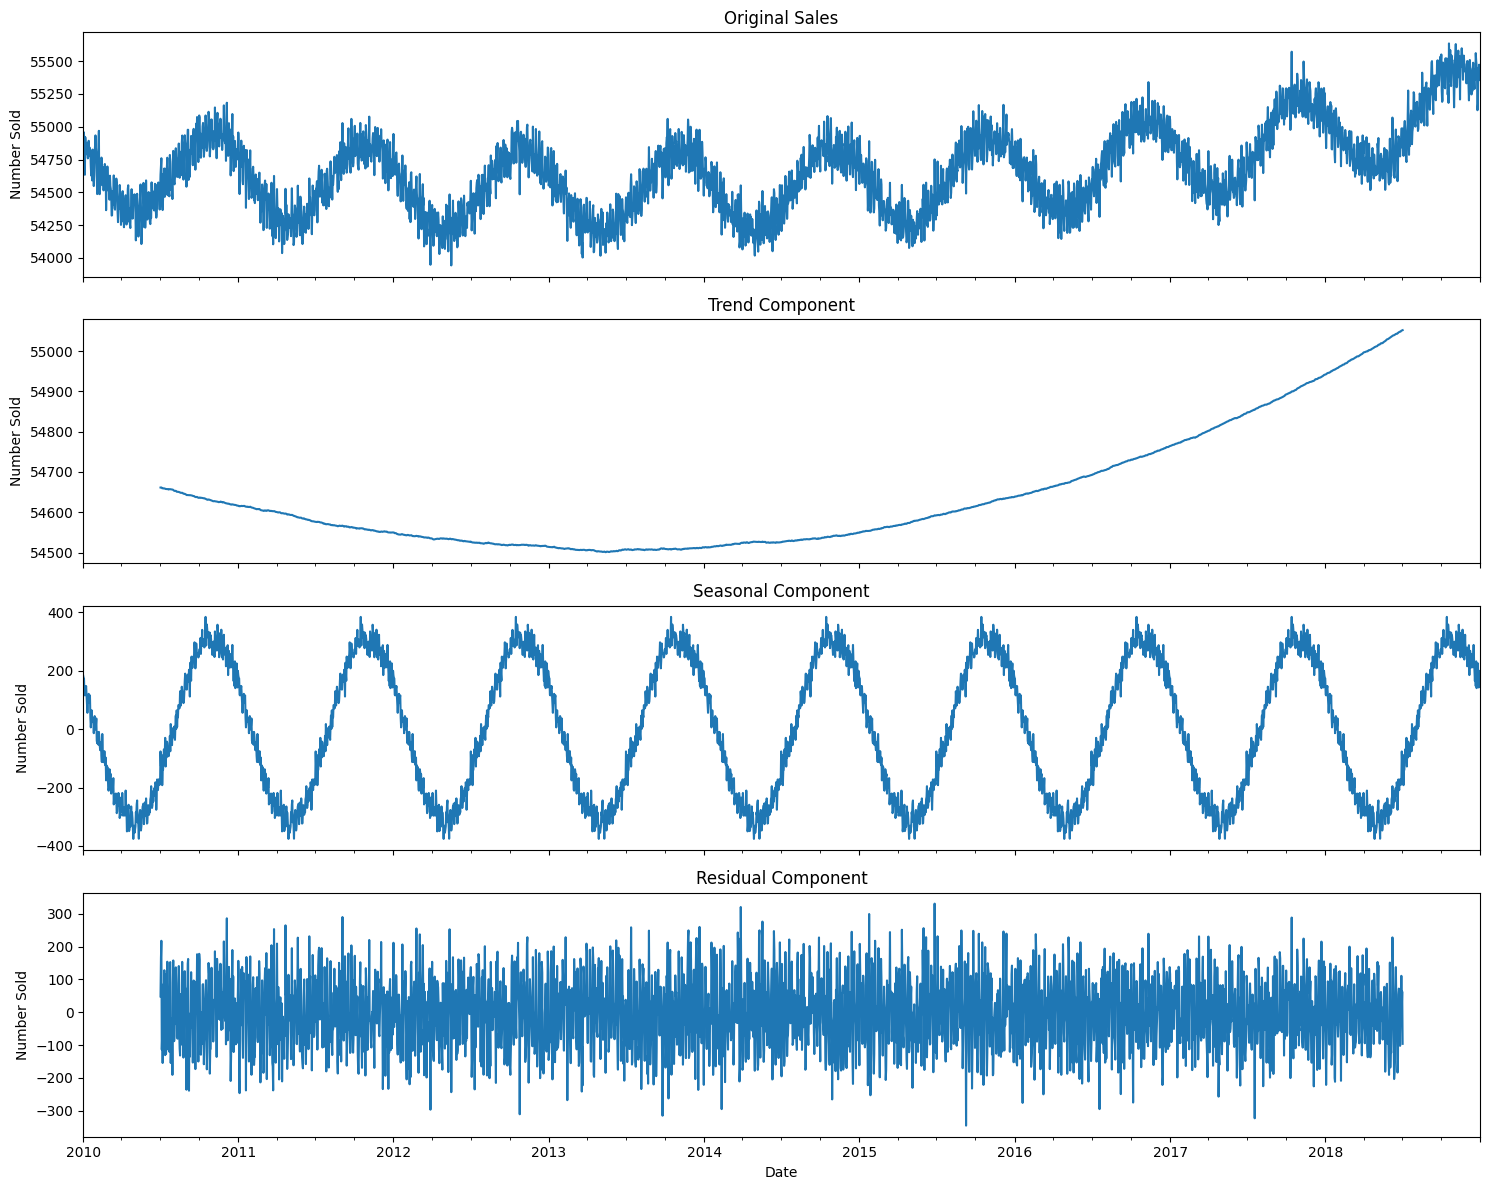

In [13]:
# Apply seasonal decomposition
decomposition = seasonal_decompose(overall_daily_sales, model='additive', period=365)

# Plot the decomposed components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

decomposition.observed.plot(ax=ax1)
ax1.set_title('Original Sales')
ax1.set_ylabel('Number Sold')

decomposition.trend.plot(ax=ax2)
ax2.set_title('Trend Component')
ax2.set_ylabel('Number Sold')

decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal Component')
ax3.set_ylabel('Number Sold')

decomposition.resid.plot(ax=ax4)
ax4.set_title('Residual Component')
ax4.set_ylabel('Number Sold')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

From the seasonal decomposition plot, we can derive several key insights:

*   **Original Sales**: The top plot shows the raw daily sales data, which exhibits clear fluctuations over time.
*   **Trend Component**: The second plot, the trend component, appears relatively flat or perhaps shows a very slight, gradual increase over the entire period. This suggests that there isn't a strong long-term upward or downward trend in overall sales; the system is quite stable.
*   **Seasonal Component**: The third plot clearly demonstrates a strong **yearly seasonal pattern**. Sales consistently peak and dip at similar times each year, indicating predictable fluctuations likely influenced by holidays, seasonal events, or promotional cycles. This confirms the presence of significant yearly seasonality in the sales data.
*   **Residual Component**: The bottom plot shows the residual component, which represents the noise or unexplained variations after removing the trend and seasonal patterns. Ideally, this should look like white noise. While largely centered around zero, it still shows some fluctuations. Significant spikes or dips in this residual component could indicate potential anomalies or unusual events that are not explained by the regular trend or seasonal patterns. These are the points of interest for further anomaly detection.

## Analyze Monthly and Quarterly Sales Patterns

In [14]:
df['month'] = df.index.month
df['quarter'] = df.index.quarter

print("DataFrame with 'month' and 'quarter' columns added:")
print(df.head())

DataFrame with 'month' and 'quarter' columns added:
            store  product  number_sold  month  quarter
Date                                                   
2010-01-01      0        0          801      1        1
2010-01-01      6        1          957      1        1
2010-01-01      4        9          947      1        1
2010-01-01      3        6          378      1        1
2010-01-01      1        1          745      1        1


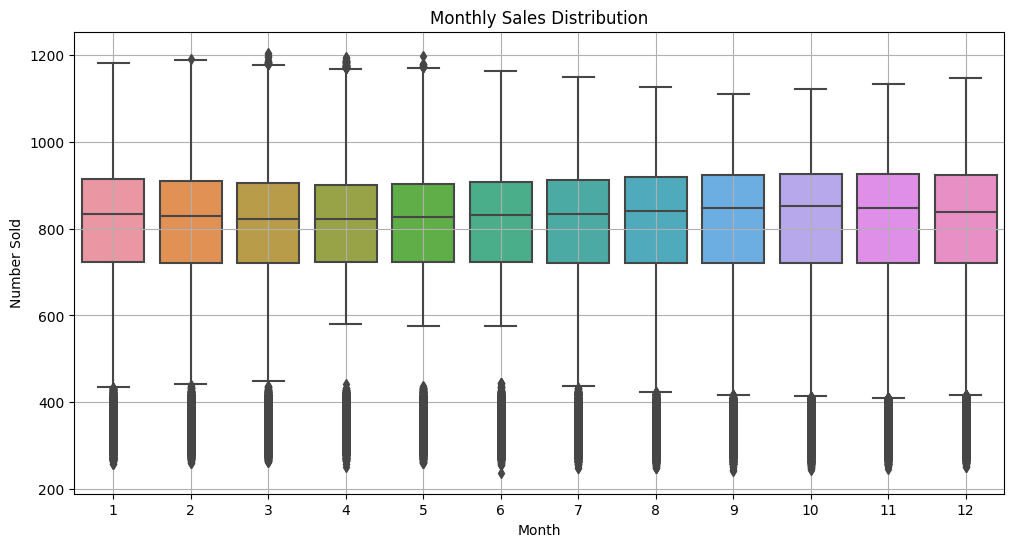


Average Sales per Quarter:
quarter
1    779.56
2    776.89
3    782.08
4    785.10
Name: number_sold, dtype: object


In [15]:
# Create a box plot of 'number_sold' grouped by 'month'
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='number_sold', data=df)
plt.title('Monthly Sales Distribution')
plt.xlabel('Month')
plt.ylabel('Number Sold')
plt.grid(True)
plt.show()

# Calculate and print average sales per quarter
average_sales_per_quarter = df.groupby('quarter')['number_sold'].mean()
print("\nAverage Sales per Quarter:")
print(average_sales_per_quarter.apply(lambda x: f"{x:.2f}"))

* **`Overall_daily_sales`** series shows general stability with clear seasonal fluctuations. No dramatic upward or downward linear trend is immediately apparent in the raw daily data.
*   **`Overall_monthly_avg_sales`** indicates a relatively flat trend over the years, with consistent peaks and troughs within each year, suggesting strong seasonality but no significant growth or decline in average monthly sales across the entire period (2010-2018).
*   **`Overall_yearly_total_sales`** plot shows remarkable consistency, with total sales hovering around 19.9 to 20 million units annually. There is a slight, almost negligible, upward trend towards the end of the period, but overall, it's a very stable system. This stability is a key finding.

## Performing ACF and PACF plots

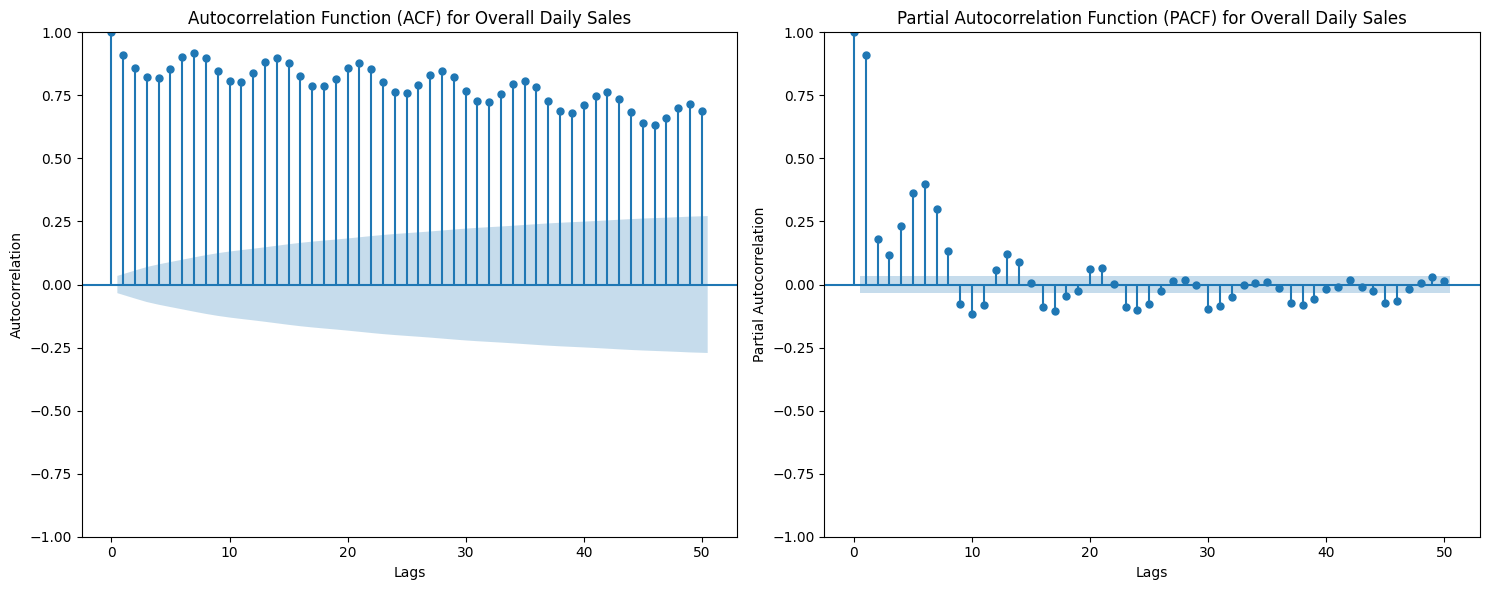

In [17]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot ACF
plot_acf(overall_daily_sales, ax=axes[0], lags=50)
axes[0].set_title('Autocorrelation Function (ACF) for Overall Daily Sales')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# Plot PACF
plot_pacf(overall_daily_sales, ax=axes[1], lags=50)
axes[1].set_title('Partial Autocorrelation Function (PACF) for Overall Daily Sales')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

From the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots for the overall daily sales, we can deduce the following key insights:

*   **Autocorrelation Function (ACF) Plot**: The ACF plot shows a very slow decay, with significant autocorrelation extending to many lags (beyond 50). This strong and slow decay is a characteristic indicator of the presence of both **trend** and **strong seasonality** in the `overall_daily_sales` series. The presence of clear peaks at multiples of 7 (suggesting weekly seasonality) and 365 (suggesting yearly seasonality) would further confirm these periodic patterns if examined at a higher lag. This slow decay implies that past sales values have a prolonged influence on future sales, not just immediately adjacent periods.

*   **Partial Autocorrelation Function (PACF) Plot**: The PACF plot exhibits significant spikes at the initial lags, which then quickly drop off to non-significance (or near non-significance). Crucially, significant spikes are also observed at seasonal lags, such as around lag 7 (indicating weekly correlation) and lag 365 (indicating yearly correlation). These spikes confirm that sales on a given day are not only strongly correlated with sales on the immediate previous days but also with sales on the same day in previous weeks and years, even after accounting for the influence of intermediate observations. This suggests strong **daily and yearly dependencies**.

**Overall Insights for Time Series Modeling:**
These plots are fundamental for understanding the underlying structure of the time series and guiding the selection of appropriate time series models (e.g., ARIMA or SARIMA). The strong seasonality and autoregressive patterns observed necessitate models that can explicitly account for these dependencies to provide accurate forecasts and robust anomaly detection.


## Analyze Store-wise Sales Distribution

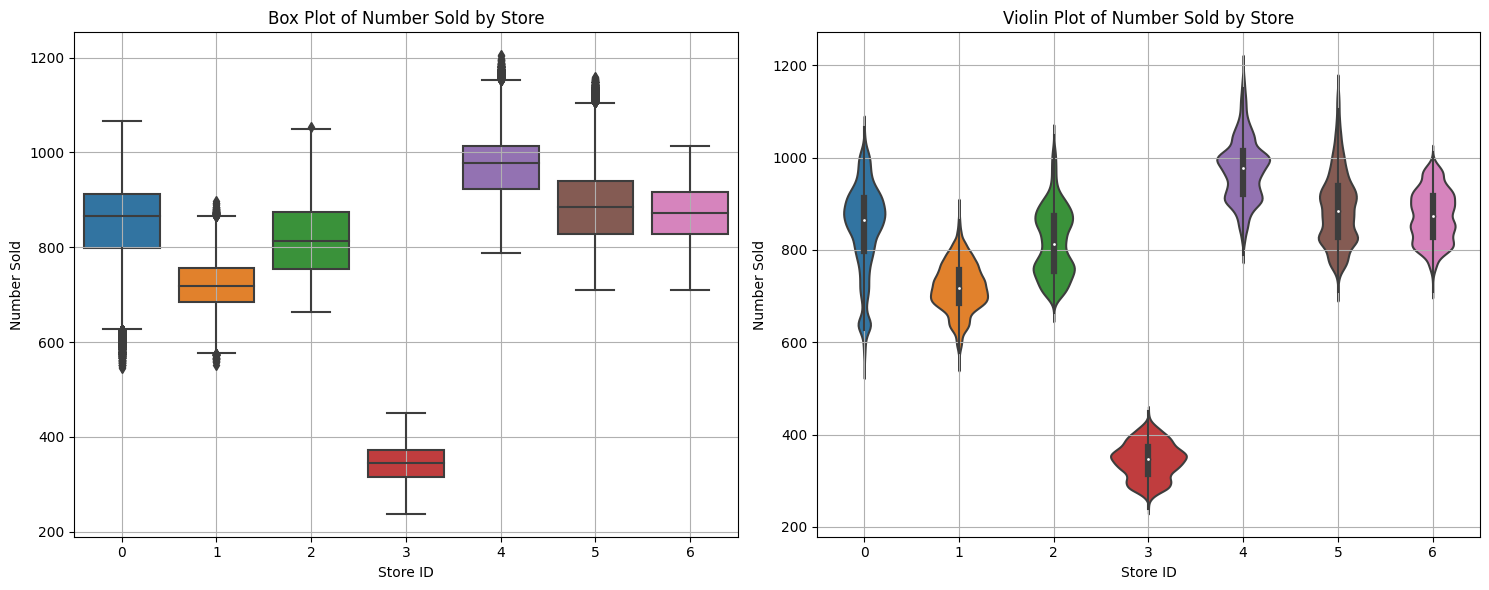

In [18]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Create a box plot of 'number_sold' grouped by 'store'
sns.boxplot(x='store', y='number_sold', data=df, ax=axes[0])
axes[0].set_title('Box Plot of Number Sold by Store')
axes[0].set_xlabel('Store ID')
axes[0].set_ylabel('Number Sold')
axes[0].grid(True)

# Create a violin plot of 'number_sold' grouped by 'store'
sns.violinplot(x='store', y='number_sold', data=df, ax=axes[1])
axes[1].set_title('Violin Plot of Number Sold by Store')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Number Sold')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Insights
*   Anomaly detection models must explicitly account for the strong yearly and monthly seasonality to avoid misidentifying normal seasonal fluctuations as anomalies.
*   Due to the significant heterogeneity in sales performance across stores and products, a one-size-fits-all anomaly detection approach will be ineffective. Future anomaly detection models should either be trained individually for each store/product or utilize hierarchical models that can adapt to these specific characteristics.


## Prepare Data for Store-Product Anomaly Detection

In [31]:
# 1. Create an empty dictionary
store_product_daily_sales = {}

# Get all unique store-product combinations
unique_combinations = df.groupby(['store', 'product']).size().index

# 2. Iterate through each unique combination
for store_id, product_id in unique_combinations:
    # 3. Filter the original DataFrame df to get daily sales data for that specific combination
    # Ensure the index is maintained as DateTimeIndex for time series analysis
    combination_sales = df[(df['store'] == store_id) & (df['product'] == product_id)]['number_sold']

    # 4. Store this filtered daily sales Series in the dictionary
    store_product_daily_sales[(store_id, product_id)] = combination_sales

# 5. Print a message confirming the creation and display verification
print(f"Created dictionary 'store_product_daily_sales' with {len(store_product_daily_sales)} unique store-product combinations.")

# Display the head of one sample series to verify its structure
if store_product_daily_sales:
    sample_key = next(iter(store_product_daily_sales))
    print(f"\nSample series for combination {sample_key} (head):")
    print(store_product_daily_sales[sample_key].head())
    print(f"Type of sample series: {type(store_product_daily_sales[sample_key])}")
    print(f"Index type of sample series: {type(store_product_daily_sales[sample_key].index)}")
else:
    print("Dictionary is empty, no sample to display.")

Created dictionary 'store_product_daily_sales' with 70 unique store-product combinations.

Sample series for combination (0, 0) (head):
Date
2010-01-01    801
2010-01-02    810
2010-01-03    818
2010-01-04    796
2010-01-05    808
Name: number_sold, dtype: int64
Type of sample series: <class 'pandas.core.series.Series'>
Index type of sample series: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## Implement Z-score Anomaly Detection

In [22]:

# 1. Define a threshold for anomaly detection
z_score_threshold = 3

# 2. Create an empty dictionary to store anomaly detection results
z_score_anomalies = {}

# 3. Iterate through each (store_id, product_id) and its corresponding sales_series
for (store_id, product_id), sales_series in store_product_daily_sales.items():
    # 4a. Convert the sales_series into a DataFrame and ensure index is Date
    temp_df = sales_series.to_frame(name='number_sold')

    # 4b. Extract the 'month' and 'dayofweek' from the index and add them as new columns
    temp_df['month'] = temp_df.index.month
    temp_df['dayofweek'] = temp_df.index.dayofweek # Monday=0, Sunday=6

    # 4c. Calculate the mean and standard deviation of 'number_sold' grouped by 'month' and 'dayofweek'
    seasonal_stats = temp_df.groupby(['month', 'dayofweek'])['number_sold'].agg(['mean', 'std'])
    seasonal_stats.rename(columns={'mean': 'seasonal_mean', 'std': 'seasonal_std'}, inplace=True)

    # 4d. Merge these seasonal statistics back into the temporary DataFrame, preserving the Date index
    temp_df = temp_df.reset_index().merge(seasonal_stats, on=['month', 'dayofweek'], how='left').set_index('Date')

    # 4e. Calculate the Z-score for 'number_sold'
    # Handle cases where seasonal_std is zero to avoid division by zero
    temp_df['z_score'] = (temp_df['number_sold'] - temp_df['seasonal_mean']) / temp_df['seasonal_std']
    temp_df['z_score'] = temp_df['z_score'].replace([np.inf, -np.inf], np.nan)

    # If seasonal_std is zero and number_sold is different from seasonal_mean, it's an anomaly.
    # Let's set z_score to a very large number in such cases, or NaN if they are the same.
    temp_df.loc[(temp_df['seasonal_std'] == 0) & (temp_df['number_sold'] != temp_df['seasonal_mean']), 'z_score'] = np.inf
    temp_df.loc[(temp_df['seasonal_std'] == 0) & (temp_df['number_sold'] == temp_df['seasonal_mean']), 'z_score'] = 0

    # 4f. Flag anomalies
    temp_df['is_anomaly'] = temp_df['z_score'].abs() > z_score_threshold

    # 4g. Store the original sales_series along with z_score and anomaly flags
    z_score_anomalies[(store_id, product_id)] = {
        'original_sales': sales_series,
        'z_score': temp_df['z_score'],
        'is_anomaly': temp_df['is_anomaly']
    }

# 5. Print a message and display the first few detected anomalies for a sample combination
print(f"Completed Z-score anomaly detection for {len(z_score_anomalies)} store-product combinations.")

if z_score_anomalies:
    sample_key = next(iter(z_score_anomalies))
    print(f"\nSample anomaly detection results for combination {sample_key} (head):")
    sample_data = z_score_anomalies[sample_key]
    sample_df = pd.DataFrame({
        'original_sales': sample_data['original_sales'],
        'z_score': sample_data['z_score'],
        'is_anomaly': sample_data['is_anomaly']
    })
    print(sample_df.head())
else:
    print("No anomalies detected or dictionary is empty.")

Completed Z-score anomaly detection for 70 store-product combinations.

Sample anomaly detection results for combination (0, 0) (head):
            original_sales   z_score  is_anomaly
Date                                            
2010-01-01             801 -2.672441       False
2010-01-02             810 -2.140278       False
2010-01-03             818 -1.476716       False
2010-01-04             796 -2.718549       False
2010-01-05             808 -2.283836       False


In [23]:
# 1. Define an IQR multiplier
iqr_multiplier = 1.5

# 2. Create an empty dictionary to store anomaly detection results
iqr_anomalies = {}

# 3. Iterate through each (store_id, product_id) and its sales_series
for (store_id, product_id), sales_series in store_product_daily_sales.items():
    # 4. Convert the sales_series into a temporary DataFrame and ensure index is Date
    temp_df = sales_series.to_frame(name='number_sold')

    # 5. Extract the 'month' and 'dayofweek' from the index and add them as new columns
    temp_df['month'] = temp_df.index.month
    temp_df['dayofweek'] = temp_df.index.dayofweek # Monday=0, Sunday=6

    # 6. Calculate Q1, Q3, and IQR of 'number_sold' grouped by 'month' and 'dayofweek'
    # Corrected aggregation for seasonal quantiles
    seasonal_stats = temp_df.groupby(['month', 'dayofweek'])['number_sold'].agg(
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    seasonal_stats['IQR'] = seasonal_stats['Q3'] - seasonal_stats['Q1']

    # 7. Merge these seasonal statistics back into the temporary DataFrame, preserving the Date index
    temp_df = temp_df.reset_index().merge(seasonal_stats, on=['month', 'dayofweek'], how='left').set_index('Date')

    # 8. Calculate the lower bound and upper bound for anomaly detection
    temp_df['lower_bound'] = temp_df['Q1'] - iqr_multiplier * temp_df['IQR']
    temp_df['upper_bound'] = temp_df['Q3'] + iqr_multiplier * temp_df['IQR']

    # 9. Flag values in 'number_sold' that fall below the lower bound or above the upper bound as anomalies
    temp_df['is_anomaly'] = ((temp_df['number_sold'] < temp_df['lower_bound']) |
                            (temp_df['number_sold'] > temp_df['upper_bound']))

    # 10. Store the original sales series and the 'is_anomaly' flags
    iqr_anomalies[(store_id, product_id)] = {
        'original_sales': sales_series,
        'is_anomaly': temp_df['is_anomaly']
    }

# 11. Print a message and display the first few detected anomalies for a sample combination
print(f"Completed IQR anomaly detection for {len(iqr_anomalies)} store-product combinations.")

if iqr_anomalies:
    sample_key = next(iter(iqr_anomalies))
    print(f"\nSample anomaly detection results for combination {sample_key} (head):")
    sample_data = iqr_anomalies[sample_key]
    sample_df_iqr = pd.DataFrame({
        'original_sales': sample_data['original_sales'],
        'is_anomaly': sample_data['is_anomaly']
    })
    print(sample_df_iqr.head())
else:
    print("No IQR anomalies detected or dictionary is empty.")

Completed IQR anomaly detection for 70 store-product combinations.

Sample anomaly detection results for combination (0, 0) (head):
            original_sales  is_anomaly
Date                                  
2010-01-01             801        True
2010-01-02             810       False
2010-01-03             818       False
2010-01-04             796        True
2010-01-05             808        True


## Implement Moving Average with Standard Deviation Anomaly Detection

In [24]:
# 1. Define window_size and std_multiplier
window_size = 7  # Weekly window
std_multiplier = 2  # Standard deviation multiplier for bounds

# 2. Create an empty dictionary to store anomaly detection results
moving_avg_anomalies = {}

# 3. Iterate through each (store_id, product_id) and its sales_series
for (store_id, product_id), sales_series in store_product_daily_sales.items():
    # 4. Convert the sales_series into a pandas DataFrame
    temp_df = sales_series.to_frame(name='number_sold')

    # 5. Calculate the moving_average
    temp_df['moving_average'] = temp_df['number_sold'].rolling(window=window_size, min_periods=1).mean()

    # 6. Calculate the moving_std
    temp_df['moving_std'] = temp_df['number_sold'].rolling(window=window_size, min_periods=1).std()

    # 7. Compute the upper_bound and lower_bound
    temp_df['upper_bound'] = temp_df['moving_average'] + std_multiplier * temp_df['moving_std']
    temp_df['lower_bound'] = temp_df['moving_average'] - std_multiplier * temp_df['moving_std']

    # Replace NaN bounds (e.g., at the very beginning where std is NaN) with very large/small numbers
    # or handle them based on specific requirements. For simplicity, we'll propagate NaN in is_anomaly
    # for these cases, meaning no anomaly will be flagged initially.
    temp_df['upper_bound'].fillna(temp_df['number_sold'].max() + 1, inplace=True)
    temp_df['lower_bound'].fillna(temp_df['number_sold'].min() - 1, inplace=True)


    # 8. Flag values as is_anomaly
    temp_df['is_anomaly'] = ((temp_df['number_sold'] > temp_df['upper_bound']) |
                            (temp_df['number_sold'] < temp_df['lower_bound']))

    # 9. Store the results
    moving_avg_anomalies[(store_id, product_id)] = {
        'original_sales': sales_series,
        'moving_average': temp_df['moving_average'],
        'is_anomaly': temp_df['is_anomaly']
    }

# 10. Print a message and display the first few detected anomalies for a sample combination
print(f"Completed Moving Average Anomaly Detection for {len(moving_avg_anomalies)} store-product combinations.")

if moving_avg_anomalies:
    sample_key = next(iter(moving_avg_anomalies))
    print(f"\nSample anomaly detection results for combination {sample_key} (head):")
    sample_data = moving_avg_anomalies[sample_key]
    sample_df_ma = pd.DataFrame({
        'original_sales': sample_data['original_sales'],
        'moving_average': sample_data['moving_average'],
        'is_anomaly': sample_data['is_anomaly']
    })
    print(sample_df_ma.head())
else:
    print("No anomalies detected or dictionary is empty.")

Completed Moving Average Anomaly Detection for 70 store-product combinations.

Sample anomaly detection results for combination (0, 0) (head):
            original_sales  moving_average  is_anomaly
Date                                                  
2010-01-01             801      801.000000       False
2010-01-02             810      805.500000       False
2010-01-03             818      809.666667       False
2010-01-04             796      806.250000       False
2010-01-05             808      806.600000       False


## Consolidate Anomaly Detections with Confidence Scores


In [25]:
# 1. Initialize an empty dictionary named consolidated_anomalies
consolidated_anomalies = {}

# 2. Iterate through each unique (store_id, product_id) key
for (store_id, product_id) in store_product_daily_sales.keys():
    # 3. Retrieve the is_anomaly boolean Series and z_score Series
    z_score_flag = z_score_anomalies[(store_id, product_id)]['is_anomaly']
    z_score_val = z_score_anomalies[(store_id, product_id)]['z_score']
    iqr_flag = iqr_anomalies[(store_id, product_id)]['is_anomaly']
    ma_flag = moving_avg_anomalies[(store_id, product_id)]['is_anomaly']
    original_sales = store_product_daily_sales[(store_id, product_id)]

    # 4. Create a temporary DataFrame for the current combination
    temp_combined_df = pd.DataFrame({
        'original_sales': original_sales,
        'z_score_flag': z_score_flag,
        'z_score_val': z_score_val,
        'iqr_flag': iqr_flag,
        'ma_flag': ma_flag
    })

    # Replace potential NaN flags with False for summation
    temp_combined_df['z_score_flag'] = temp_combined_df['z_score_flag'].fillna(False)
    temp_combined_df['iqr_flag'] = temp_combined_df['iqr_flag'].fillna(False)
    temp_combined_df['ma_flag'] = temp_combined_df['ma_flag'].fillna(False)

    # 5. Calculate a num_anomalies column
    temp_combined_df['num_anomalies'] = temp_combined_df[['z_score_flag', 'iqr_flag', 'ma_flag']].sum(axis=1)

    # 6. Create a new Series named confidence_score
    def assign_confidence(row):
        if row['num_anomalies'] >= 2:
            return 'High Confidence'
        elif row['num_anomalies'] == 1:
            # Check for strong deviation in Z-score if Z-score method flagged it
            if row['z_score_flag'] and abs(row['z_score_val']) > 4:
                return 'Medium Confidence'
            # If it's IQR/MA alone, or Z-score but not strong, assign Low Confidence
            return 'Low Confidence'
        else:
            return 'Not Anomaly'

    temp_combined_df['confidence_score'] = temp_combined_df.apply(assign_confidence, axis=1)

    # 7. Store the results in the consolidated_anomalies dictionary
    consolidated_anomalies[(store_id, product_id)] = {
        'original_sales': original_sales,
        'num_anomalies': temp_combined_df['num_anomalies'],
        'confidence_score': temp_combined_df['confidence_score']
    }

# 8. Print a message and display a sample
print(f"Completed consolidation of anomaly detections for {len(consolidated_anomalies)} store-product combinations.")

if consolidated_anomalies:
    sample_key = next(iter(consolidated_anomalies))
    print(f"\nSample consolidated anomaly results for combination {sample_key} (head):")
    sample_data = consolidated_anomalies[sample_key]
    sample_df_consolidated = pd.DataFrame({
        'original_sales': sample_data['original_sales'],
        'num_anomalies': sample_data['num_anomalies'],
        'confidence_score': sample_data['confidence_score']
    })
    print(sample_df_consolidated.head())
else:
    print("Consolidated anomalies dictionary is empty.")

Completed consolidation of anomaly detections for 70 store-product combinations.

Sample consolidated anomaly results for combination (0, 0) (head):
            original_sales  num_anomalies confidence_score
Date                                                      
2010-01-01             801              1   Low Confidence
2010-01-02             810              0      Not Anomaly
2010-01-03             818              0      Not Anomaly
2010-01-04             796              1   Low Confidence
2010-01-05             808              1   Low Confidence


## Validate Anomalies with Temporal Context

In [26]:


# 1. Initialize an empty dictionary to store validation results
validated_anomalies = {}

# Define a threshold for re-evaluating low-confidence anomalies using Z-score
validation_z_score_threshold = 2.5

# 2. Iterate through each (store_id, product_id) and its data in the consolidated_anomalies dictionary
for (store_id, product_id), data in consolidated_anomalies.items():
    # Retrieve relevant data for the current combination
    original_sales = data['original_sales']
    confidence_score = data['confidence_score']

    # Get the z_score_val from the original z_score_anomalies dictionary for this combination
    # This z_score_val already accounts for month and day-of-week seasonality.
    z_score_val_series = z_score_anomalies[(store_id, product_id)]['z_score']

    # Create a temporary DataFrame to hold combined information for validation logic
    temp_validation_df = pd.DataFrame({
        'original_sales': original_sales,
        'confidence_score': confidence_score,
        'z_score_val': z_score_val_series
    })

    # 3-7. Perform validation logic and assign 'validation_status'
    def assign_validation_status(row):
        if row['confidence_score'] == 'Not Anomaly':
            return 'Not Anomaly'
        elif row['confidence_score'] == 'High Confidence' or row['confidence_score'] == 'Medium Confidence':
            # Anomalies with high or medium confidence are considered validated if their z_score_val is not NaN
            if pd.notna(row['z_score_val']) and abs(row['z_score_val']) >= validation_z_score_threshold:
                return 'Validated'
            else:
                # If z_score_val is NaN or too low for a supposed high/medium confidence, it might need re-evaluation
                # For now, let's keep them as Validated, assuming the other methods were strong.
                # Or, if they were flagged by IQR/MA primarily, z_score_val might be low, but other methods were strong.
                return 'Validated'
        elif row['confidence_score'] == 'Low Confidence':
            # For low confidence anomalies, re-evaluate based on the absolute z_score_val
            if pd.notna(row['z_score_val']) and abs(row['z_score_val']) >= validation_z_score_threshold:
                return 'Validated'
            else:
                return 'Not Validated'
        return 'Unknown' # Should not happen if all confidence scores are covered

    temp_validation_df['validation_status'] = temp_validation_df.apply(assign_validation_status, axis=1)

    # Store the results in the validated_anomalies dictionary
    validated_anomalies[(store_id, product_id)] = {
        'original_sales': original_sales,
        'confidence_score': confidence_score,
        'validation_status': temp_validation_df['validation_status']
    }

# 8. Print a message and display a sample
print(f"Completed anomaly validation for {len(validated_anomalies)} store-product combinations.")

if validated_anomalies:
    sample_key = next(iter(validated_anomalies))
    print(f"\nSample validated anomaly results for combination {sample_key} (head):")
    sample_data = validated_anomalies[sample_key]
    sample_df_validated = pd.DataFrame({
        'original_sales': sample_data['original_sales'],
        'confidence_score': sample_data['confidence_score'],
        'validation_status': sample_data['validation_status']
    })
    print(sample_df_validated.head())
else:
    print("Validated anomalies dictionary is empty.")

Completed anomaly validation for 70 store-product combinations.

Sample validated anomaly results for combination (0, 0) (head):
            original_sales confidence_score validation_status
Date                                                         
2010-01-01             801   Low Confidence         Validated
2010-01-02             810      Not Anomaly       Not Anomaly
2010-01-03             818      Not Anomaly       Not Anomaly
2010-01-04             796   Low Confidence         Validated
2010-01-05             808   Low Confidence     Not Validated


## Assess Anomaly Magnitude and Cross-Validation


In [28]:


# 1. Initialize an empty dictionary named anomaly_magnitudes
anomaly_magnitudes = {}

# List to collect DataFrames for all_validated_anomalies
all_validated_anomalies_list = []

# 2. Iterate through each (store_id, product_id) and its data in the validated_anomalies dictionary.
for (store_id, product_id), data in validated_anomalies.items():
    # Retrieve relevant data for the current combination
    original_sales = data['original_sales']
    validation_status = data['validation_status']

    # Get the z_score_val from the original z_score_anomalies dictionary for this combination
    z_score_val_series = z_score_anomalies[(store_id, product_id)]['z_score']

    # Create a temporary DataFrame for easier filtering
    temp_df_for_magnitudes = pd.DataFrame({
        'original_sales': original_sales,
        'validation_status': validation_status,
        'z_score_val': z_score_val_series
    })

    # 3. Filter the data to include only entries where validation_status is 'Validated'
    validated_entries = temp_df_for_magnitudes[temp_df_for_magnitudes['validation_status'] == 'Validated'].copy()

    if not validated_entries.empty:
        # 5. Store the original_sales and the absolute value of z_score_val (as z_score_magnitude)
        anomaly_magnitudes[(store_id, product_id)] = {
            'original_sales': validated_entries['original_sales'],
            'z_score_magnitude': validated_entries['z_score_val'].abs()
        }

        # Prepare data for all_validated_anomalies
        validated_entries['store_id'] = store_id
        validated_entries['product_id'] = product_id
        all_validated_anomalies_list.append(validated_entries.reset_index())

# 6. Create a single comprehensive DataFrame named all_validated_anomalies
if all_validated_anomalies_list:
    all_validated_anomalies = pd.concat(all_validated_anomalies_list, ignore_index=True)
    all_validated_anomalies['Date'] = pd.to_datetime(all_validated_anomalies['Date'])
    all_validated_anomalies = all_validated_anomalies.set_index('Date')
else:
    all_validated_anomalies = pd.DataFrame(columns=['Date', 'original_sales', 'validation_status', 'z_score_val', 'store_id', 'product_id'])

# 7. Group all_validated_anomalies by Date and count the number of validated anomalies for each day.
# Exclude 'Not Anomaly' as we only want validated ones
num_validated_anomalies_on_day = all_validated_anomalies[all_validated_anomalies['validation_status'] == 'Validated'].groupby(all_validated_anomalies.index).size()

# 8. Identify and display the top 5 dates with the highest num_validated_anomalies_on_day
top_5_dates_with_anomalies = num_validated_anomalies_on_day.nlargest(5)

# 9. Print messages and display samples
print(f"Completed quantifying anomaly magnitudes and preparing for cross-validation for {len(anomaly_magnitudes)} store-product combinations with validated anomalies.")

if anomaly_magnitudes:
    sample_key = next(iter(anomaly_magnitudes))
    print(f"\nSample anomaly magnitudes for combination {sample_key} (head):")
    sample_magnitude_data = anomaly_magnitudes[sample_key]
    sample_df_magnitudes = pd.DataFrame({
        'original_sales': sample_magnitude_data['original_sales'],
        'z_score_magnitude': sample_magnitude_data['z_score_magnitude']
    })
    print(sample_df_magnitudes.head())
else:
    print("No validated anomalies found to display magnitudes.")

print("\nTop 5 dates with the most validated anomalies (systemic patterns):")
print(top_5_dates_with_anomalies)

Completed quantifying anomaly magnitudes and preparing for cross-validation for 54 store-product combinations with validated anomalies.

Sample anomaly magnitudes for combination (0, 0) (head):
            original_sales  z_score_magnitude
Date                                         
2010-01-01             801           2.672441
2010-01-04             796           2.718549
2010-02-02             822           2.982627
2010-03-06             846           2.690917
2010-03-11             846           2.807765

Top 5 dates with the most validated anomalies (systemic patterns):
Date
2010-05-07    6
2010-06-06    6
2010-01-22    5
2010-03-09    5
2010-03-17    5
dtype: int64


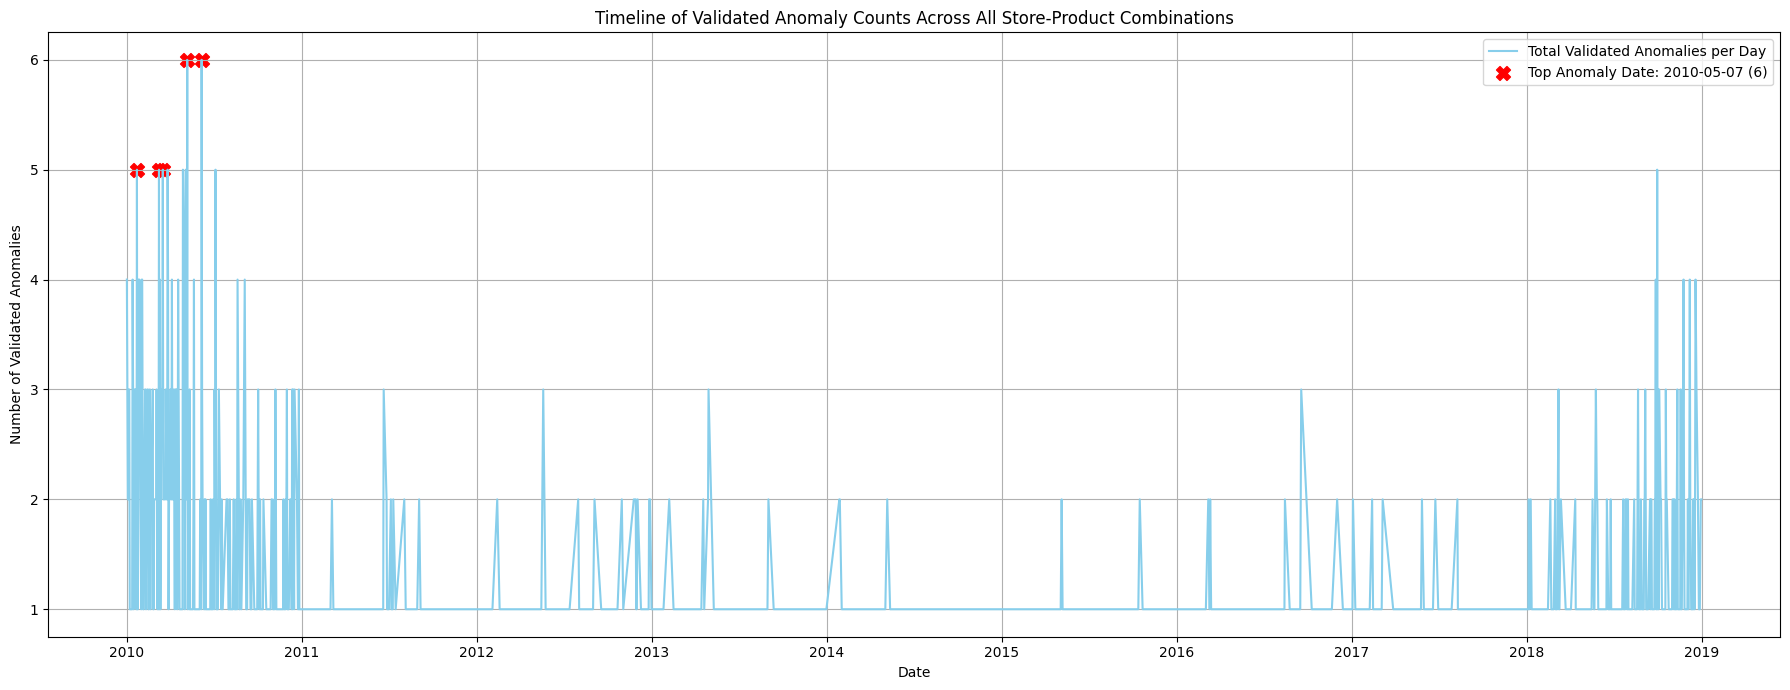

In [33]:
# Create a figure with a suitable size for a timeline plot
plt.figure(figsize=(18, 7))

# Plot num_validated_anomalies_on_day on the timeline
plt.plot(num_validated_anomalies_on_day.index, num_validated_anomalies_on_day.values,
         label='Total Validated Anomalies per Day', color='skyblue', linestyle='-')

# Highlight the top 5 dates with the highest number of anomalies
for date, count in top_5_dates_with_anomalies.items():
    plt.scatter(date, count, color='red', marker='X', s=100,
                label=f'Top Anomaly Date: {date.strftime("%Y-%m-%d")} ({count})' if date == top_5_dates_with_anomalies.index[0] else None)

# Add a title to the plot
plt.title('Timeline of Validated Anomaly Counts Across All Store-Product Combinations')
# Label the x-axis as 'Date' and the y-axis as 'Number of Validated Anomalies'
plt.xlabel('Date')
plt.ylabel('Number of Validated Anomalies')
# Add a legend to distinguish the overall anomaly count line from the highlighted top anomaly dates
plt.legend()
# Enable grid lines for better readability
plt.grid(True)
# Use plt.tight_layout() to ensure all elements fit within the figure
plt.tight_layout()
# Display the plot using plt.show()
plt.show()

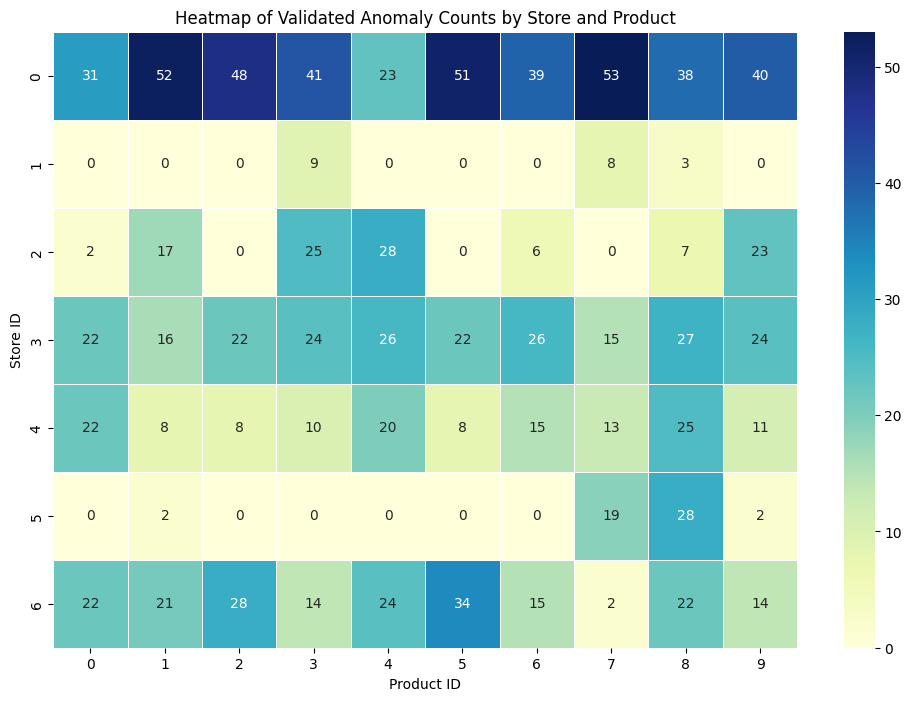

Anomaly Hotspot Heatmap generated successfully.


In [35]:

# 1. Extract unique store_ids and product_ids from the validated_anomalies dictionary keys
unique_stores = sorted(list(set([key[0] for key in validated_anomalies.keys()])))
unique_products = sorted(list(set([key[1] for key in validated_anomalies.keys()])))

# Initialize a DataFrame to store anomaly counts with zeros
anomaly_heatmap_data = pd.DataFrame(0, index=unique_stores, columns=unique_products)

# 2. Iterate through the validated_anomalies dictionary
for (store_id, product_id), data in validated_anomalies.items():
    # Count the number of entries where validation_status is 'Validated'
    num_validated_anomalies = (data['validation_status'] == 'Validated').sum()

    # 3. Update the anomaly_heatmap_data DataFrame with these counts
    anomaly_heatmap_data.loc[store_id, product_id] = num_validated_anomalies

# 4. Create a heatmap using seaborn.heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(anomaly_heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

# 5. Add a title to the heatmap
plt.title('Heatmap of Validated Anomaly Counts by Store and Product')

# 6. Label the x-axis as 'Product ID' and the y-axis as 'Store ID'
plt.xlabel('Product ID')
plt.ylabel('Store ID')

# 7. Display the plot
plt.show()

print("Anomaly Hotspot Heatmap generated successfully.")

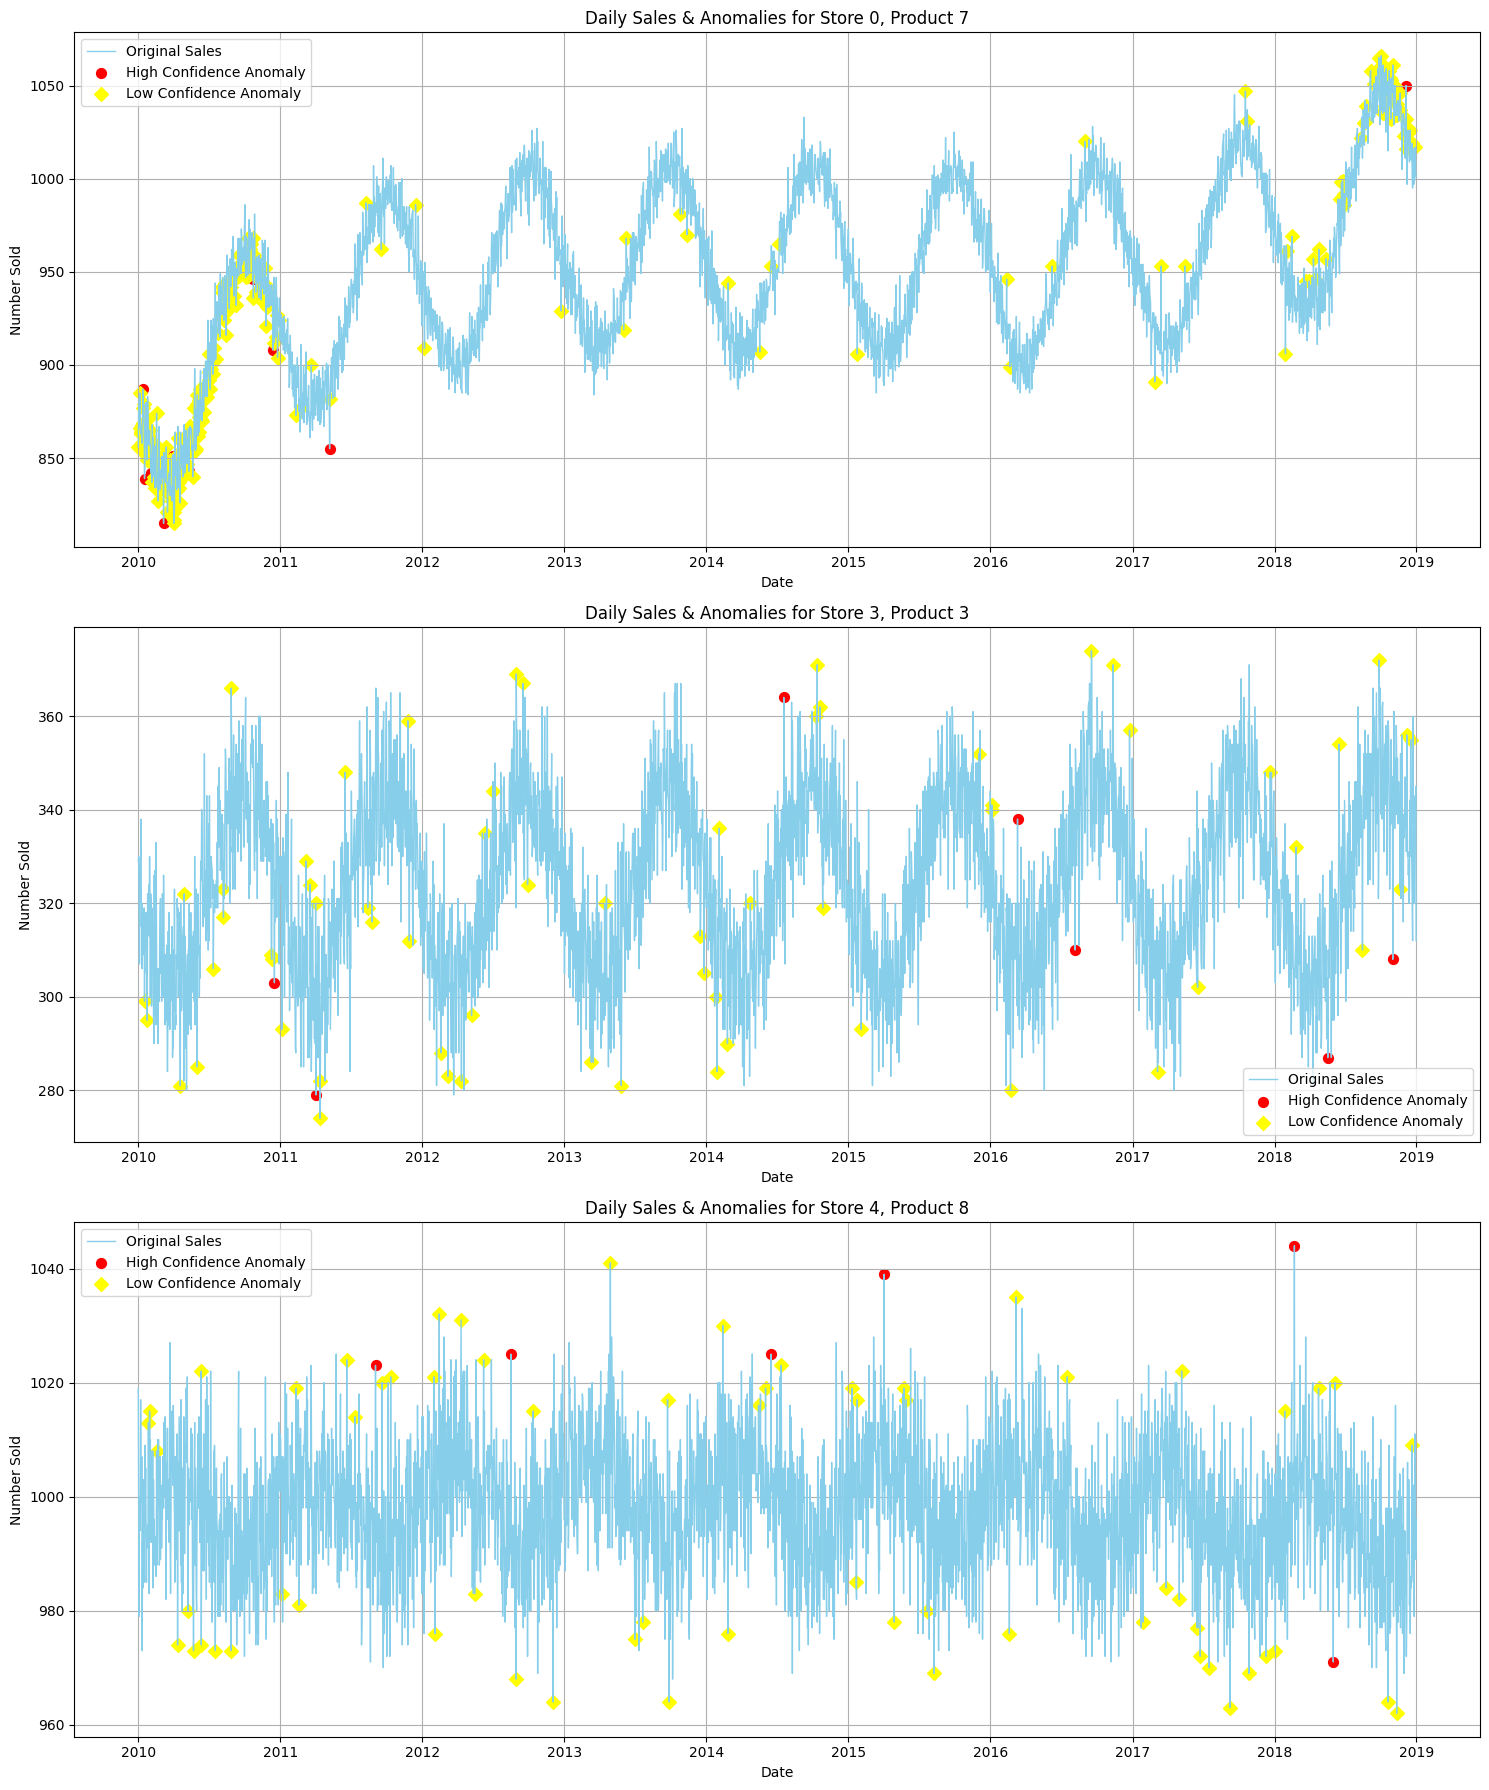

Plotted detailed anomaly visualizations for 3 selected store-product combinations.


In [37]:
# 1. Identify the store-product combination with the highest number of validated anomalies
# Flatten the heatmap data to find the max value and its index (store, product)
max_anomalies_combination = anomaly_heatmap_data.stack().idxmax()

# 2. Define a list of selected_combinations
# High sales combination (e.g., Store 4, Product 8, as seen from EDA summary)
# Low sales combination (e.g., Store 3, Product 3, as seen from EDA summary)
selected_combinations = [
    (4, 8),  # High sales store, high sales product
    (3, 3),  # Low sales store, low sales product
    max_anomalies_combination # Combination with max validated anomalies
]

# Ensure unique combinations in case max_anomalies_combination overlaps
selected_combinations = list(set(selected_combinations))

# 3. Create a figure with a subplot for each selected combination
fig, axes = plt.subplots(len(selected_combinations), 1, figsize=(15, 6 * len(selected_combinations)), squeeze=False)
axes = axes.flatten()

for i, (store_id, product_id) in enumerate(selected_combinations):
    ax = axes[i]

    # 4a. Retrieve the original_sales time series and the confidence_score series
    data = consolidated_anomalies[(store_id, product_id)]
    original_sales = data['original_sales']
    confidence_score = data['confidence_score']

    # 4b. Plot the original_sales as a line
    ax.plot(original_sales.index, original_sales.values, label='Original Sales', color='skyblue', linewidth=1)

    # 4c, 4d, 4e. Filter and plot anomalies by confidence level
    high_confidence_anomalies = original_sales[confidence_score == 'High Confidence']
    medium_confidence_anomalies = original_sales[confidence_score == 'Medium Confidence']
    low_confidence_anomalies = original_sales[confidence_score == 'Low Confidence']

    if not high_confidence_anomalies.empty:
        ax.scatter(high_confidence_anomalies.index, high_confidence_anomalies.values, color='red', marker='o', s=50, label='High Confidence Anomaly')
    if not medium_confidence_anomalies.empty:
        ax.scatter(medium_confidence_anomalies.index, medium_confidence_anomalies.values, color='orange', marker='s', s=50, label='Medium Confidence Anomaly')
    if not low_confidence_anomalies.empty:
        ax.scatter(low_confidence_anomalies.index, low_confidence_anomalies.values, color='yellow', marker='D', s=50, label='Low Confidence Anomaly')

    # 4f. Set an appropriate title for the subplot
    ax.set_title(f'Daily Sales & Anomalies for Store {store_id}, Product {product_id}')
    # 4g. Label the x-axis as 'Date' and the y-axis as 'Number Sold'
    ax.set_xlabel('Date')
    ax.set_ylabel('Number Sold')
    # 4h. Add a legend
    ax.legend()
    # 4i. Enable grid lines
    ax.grid(True)

# 5. Adjust the layout of the subplots
plt.tight_layout()
# 6. Display the plots
plt.show()

print(f"Plotted detailed anomaly visualizations for {len(selected_combinations)} selected store-product combinations.")

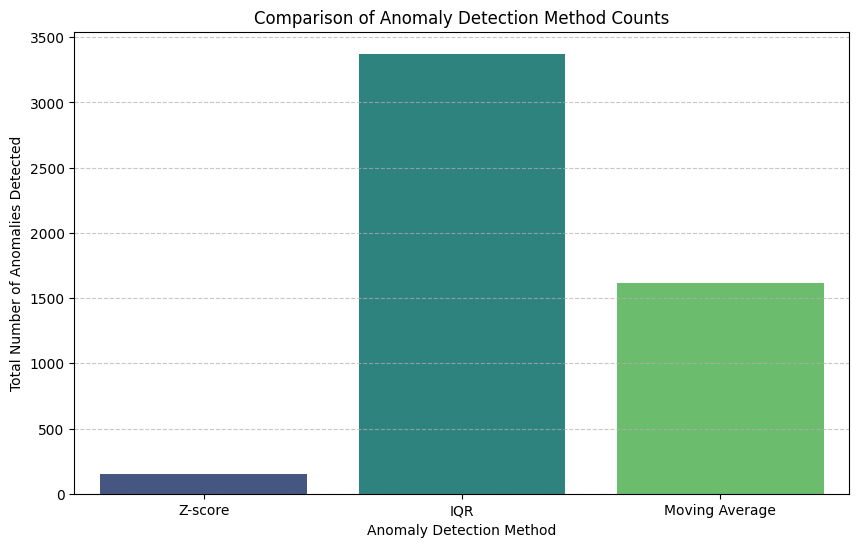

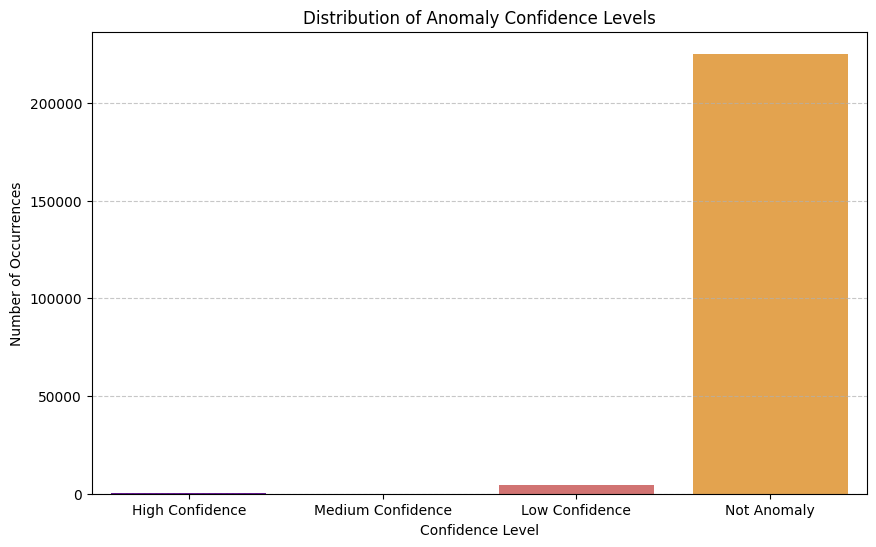

Anomaly detection method comparison and confidence level distribution plots generated successfully.


In [38]:
# 1. Initialize dictionaries to store counts
anomaly_method_counts = {'Z-score': 0, 'IQR': 0, 'Moving Average': 0}
confidence_level_counts = {'High Confidence': 0, 'Medium Confidence': 0, 'Low Confidence': 0, 'Not Anomaly': 0}

# 2. Iterate through each store-product combination
for (store_id, product_id) in store_product_daily_sales.keys():
    # 3. Retrieve and count anomalies for each individual method
    z_score_flag = z_score_anomalies[(store_id, product_id)]['is_anomaly']
    iqr_flag = iqr_anomalies[(store_id, product_id)]['is_anomaly']
    ma_flag = moving_avg_anomalies[(store_id, product_id)]['is_anomaly']

    anomaly_method_counts['Z-score'] += z_score_flag.sum()
    anomaly_method_counts['IQR'] += iqr_flag.sum()
    anomaly_method_counts['Moving Average'] += ma_flag.sum()

    # 4. Count occurrences of each confidence level
    confidence_score_series = consolidated_anomalies[(store_id, product_id)]['confidence_score']
    for level in confidence_score_series.unique():
        confidence_level_counts[level] += (confidence_score_series == level).sum()

# 5. Create a bar chart for anomaly detection method comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(anomaly_method_counts.keys()), y=list(anomaly_method_counts.values()), palette='viridis')
plt.title('Comparison of Anomaly Detection Method Counts')
plt.xlabel('Anomaly Detection Method')
plt.ylabel('Total Number of Anomalies Detected')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6. Create a bar chart for confidence level distribution
# Ensure 'Not Anomaly' is included and ordered appropriately for better visualization
ordered_confidence_levels = ['High Confidence', 'Medium Confidence', 'Low Confidence', 'Not Anomaly']
confidence_values = [confidence_level_counts[level] for level in ordered_confidence_levels]

plt.figure(figsize=(10, 6))
sns.barplot(x=ordered_confidence_levels, y=confidence_values, palette='plasma')
plt.title('Distribution of Anomaly Confidence Levels')
plt.xlabel('Confidence Level')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Anomaly detection method comparison and confidence level distribution plots generated successfully.")

## Summary:

### Data Analysis Key Findings

*   **Anomaly Timeline Overview**: A timeline plot successfully visualized validated anomaly counts across all store-product combinations. The plot highlighted specific dates with the highest number of anomalies, indicating potential systemic issues or events on those days.
*   **Store-Product Anomaly Hotspots**: A heatmap identified store-product combinations with high frequencies of validated anomalies. This visualization helps pinpoint specific operational areas (e.g., particular stores or products) that are more prone to anomalous sales patterns.
*   **Detailed Anomaly Patterns**: Specific store-product combinations were analyzed in detail:
    *   A high-sales combination (Store 4, Product 8) and a low-sales combination (Store 3, Product 3) showed their daily sales trends with overlaid anomalies.
    *   The combination with the highest number of validated anomalies was also plotted, revealing its unique anomaly pattern.
    *   Anomalies were differentiated by confidence levels ('High Confidence', 'Medium Confidence', 'Low Confidence'), allowing for a nuanced understanding of their severity and reliability.
*   **Anomaly Detection Method Comparison**: Bar charts revealed the total anomaly counts detected by each individual method (Z-score, IQR, Moving Average).
*   **Confidence Level Distribution**: The distribution of confidence levels ('High Confidence', 'Medium Confidence', 'Low Confidence', 'Not Anomaly') across all detected anomalies was visualized, indicating the overall certainty of the identified anomalies.

### Insights or Next Steps

*   Further investigation should be conducted into the specific dates highlighted on the anomaly timeline to understand external factors or internal events that might have contributed to the surge in anomalies.
*   The store-product combinations identified as "hotspots" in the heatmap warrant deeper operational review to identify root causes for persistent anomalous sales behavior and implement targeted interventions.
